# Кластеризация сцинтилляционных сигналов для разделения гамма-квантов, нейтронов и аномальных событий

Выполнил:
Чувиль Альна Германовна

Цель проекта

Разработать воспроизводимое решение задачи кластеризации сигналов сцинтилляционного детектора на три группы:

- сигналы первого типа частиц;
- сигналы второго типа частиц;
- аномальные или неидентифицируемые сигналы.

Для решения задачи используются методы машинного обучения без учителя, включая анализ данных, извлечение признаков, снижение размерности и сравнение нескольких алгоритмов кластеризации.

Задачи проекта

1. Выполнить разведочный анализ данных (EDA).
2. Провести предобработку признаков.
3. Выполнить Feature Engineering.
4. Исследовать структуру данных методами снижения размерности.
5. Сравнить несколько алгоритмов кластеризации.
6. Подобрать гиперпараметры моделей.
7. Выбрать лучшее решение.
8. Сформировать submission для Kaggle.
9. Проанализировать результаты и сделать выводы.  

### Kaggle score  
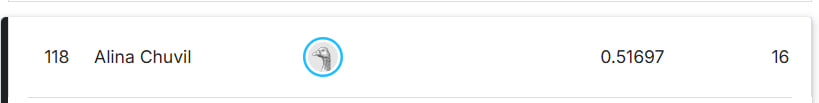

Содержание

1. Импорт библиотек
2. Загрузка и первичное изучение данных
3. Разведочный анализ данных (EDA)
4. Предобработка данных
5. Feature Engineering
6. Снижение размерности
7. Базовые алгоритмы кластеризации
8. Продвинутые алгоритмы кластеризации
9. Подбор гиперпараметров
10. Выбор лучшей модели
11. Формирование Kaggle Submission
12. Анализ результата Kaggle
13. Итоговые выводы

## ШАГ 1. ИМПОРТ БИБЛИОТЕК

In [83]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import kurtosis, skew

from sklearn.cluster import (
    AgglomerativeClustering,
    DBSCAN,
    KMeans,
)
from sklearn.decomposition import PCA
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import (
    MinMaxScaler,
    RobustScaler,
    StandardScaler,
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_style("whitegrid")

Библиотеки успешно загружены.


## Шаг 2. ЗАГРУЗКА ДАННЫХ

In [84]:
DATA_PATH = "Run200_Wave_0_1.txt"

df = pd.read_csv(
    DATA_PATH,
    sep=r"\s+",
    header=None
)
print(f"Размер датасета: {df.shape}")

Размер датасета: (23479, 504)


In [85]:
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499,500,501,502,503
0,2890276,357,113,500,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820,14820,14822,14824,14820,14828,14819,14822,14822,14820,14822,14820,14819,14820,14821,14815,14830,14824,14825,14820,14820,14824,14822,14817,14825,14820,14814,14822,14823,14824,14820,14820,14823,14822,14817,14824,14826,14823,14822,14818,14822,14820,14817,14820,14821,14822,14820,14818,14820,14820,14825,14818,14819,14824,14822,14818,14820,14827,14826,14824,14819,14820,14822,14820,14820,14822,14825,14822,14821,14817,14822,14819,14821,14823,14821,14817,14820,14827,14820,14820,14823,14820,14815,14820,14822,14820,14824,14817,14818,14819,14822,14819,14818,14827,14820,14818,14820,14819,14818,14820,14824,14822,14820,14817,14822,14820,14817,14824,14822,14823,14824,14820,14825,14818,14823,14817,14820,14824,14824,14815,14820,14820,14822,14817,14822,14820,14820,14820,14822,14820,14819,14818,14823,14818,14818,14820,14814,14763,14563,14378,14291,14378,14460,14532,14607,14630,14681,14732,14741,14748,14756,14772,14779,14790,14792,14799,14801,14799,14797,14792,14803,14798,14794,14794,14814,14808,14811,14810,14807,14815,14810,14807,14801,14804,14804,14801,14801,14810,14806,14791,14813,14799,14802,14804,14811,14812,14803,14803,14812,14816,14819,14812,14809,14817,14817,14815,14817,14820,14817,14812,14816,14819,14816,14815,14822,14806,14817,14809,14813,14810,14813,14812,14819,14812,14815,14812,14823,14810,14810,14819,14819,14822,14813,14816,14820,14816,14817,14820,14819,14817,14821,14820,14826,14819,14820,14820,14826,14819,14821,14812,14820,14817,14813,14812,14815,14815,14814,14817,14817,14817,14815,14814,14820,14815,14813,14810,14820,14822,14821,14818,14818,14819,14820,14812,14818,14820,14816,14818,14819,14817,14819,14820,14816,14817,14816,14819,14819,14818,14818,14817,14820,14818,14824,14823,14813,14817,14818,14815,14825,14819,14827,14818,14815,14820,14823,14815,14822,14827,14822,14818,14818,14818,14822,14812,14830,14819,14817,14823,14828,14824,14810,14817,14827,14823,14814,14820,14821,14820,14816,14818,14828,14818,14822,14819,14823,14817,14816,14824,14822,14823,14818,14822,14825,14820,14823,14818,1

In [86]:
# Размерность данных

print(f"Количество объектов: {df.shape[0]}")
print(f"Количество признаков: {df.shape[1]}")

Количество объектов: 23479
Количество признаков: 504


In [87]:
# Просмотр случайных объектов

df.sample(5, random_state=RANDOM_STATE)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499,500,501,502,503
13473,115953447456,896,452,500,14820,14824,14822,14823,14824,14819,14820,14825,14828,14822,14820,14821,14828,14823,14820,14828,14824,14822,14819,14823,14824,14827,14824,14822,14822,14824,14815,14821,14820,14816,14823,14826,14823,14820,14824,14823,14819,14827,14816,14822,14824,14823,14822,14823,14823,14821,14823,14824,14824,14823,14823,14828,14812,14821,14826,14822,14823,14817,14819,14828,14820,14818,14820,14823,14828,14823,14820,14822,14824,14820,14820,14821,14826,14822,14820,14824,14820,14824,14820,14820,14823,14820,14820,14824,14819,14822,14823,14820,14819,14822,14820,14822,14824,14822,14823,14821,14822,14820,14816,14828,14822,14820,14827,14819,14828,14820,14824,14822,14828,14828,14820,14822,14824,14819,14820,14822,14827,14824,14820,14820,14824,14823,14827,14821,14826,14817,14824,14826,14826,14819,14827,14826,14820,14821,14820,14818,14824,14826,14818,14823,14824,14823,14820,14817,14819,14824,14804,14714,14210,13417,12728,12506,12816,13284,13719,14083,14286,14449,14532,14590,14628,14693,14726,14722,14745,14748,14766,14789,14787,14778,14792,14798,14801,14795,14785,14790,14796,14792,14804,14805,14811,14808,14812,14800,14804,14808,14818,14805,14817,14813,14807,14815,14808,14813,14804,14816,14819,14816,14816,14810,14818,14814,14818,14816,14823,14815,14820,14813,14820,14820,14819,14813,14824,14822,14820,14820,14817,14814,14817,14822,14823,14818,14818,14822,14822,14819,14819,14813,14818,14820,14820,14826,14824,14820,14824,14820,14823,14819,14812,14814,14811,14819,14818,14820,14820,14826,14819,14818,14820,14812,14818,14821,14826,14821,14820,14824,14820,14814,14815,14817,14819,14819,14820,14820,14822,14824,14822,14824,14823,14823,14823,14819,14822,14825,14819,14820,14828,14819,14820,14828,14820,14818,14824,14827,14824,14822,14823,14818,14822,14821,14820,14826,14828,14820,14824,14820,14824,14821,14826,14818,14819,14819,14816,14819,14820,14820,14822,14818,14822,14819,14824,14823,14822,14822,14824,14819,14827,14819,14819,14825,14823,14821,14827,14825,14817,14823,14819,14823,14823,14820,14824,14821,14817,14823,14820,14817,14822,14820,14826,14826,14822,14820,14820,1482

Вывод

После загрузки набора данных установлено, что выборка содержит 23 479 зарегистрированных сигналов, каждый из которых описывается 504 признаками.

Структура данных позволяет предположить, что первые несколько столбцов содержат служебные характеристики сигнала, тогда как основная часть признаков представляет собой последовательность отсчётов формы импульса, зарегистрированного сцинтилляционным детектором.

Высокая размерность пространства признаков делает актуальными методы предобработки и снижения размерности, которые будут использоваться на следующих этапах исследования.

Поскольку данные относятся к физическим сигналам, особый интерес представляет анализ формы импульсов и извлечение информативных характеристик, которые могут помочь в разделении различных типов частиц.

## Шаг 3. Разведочный анализ данных (EDA)

На данном этапе проводится исследование структуры набора данных.

Основные задачи анализа:

- проверить наличие пропусков и дубликатов;
- изучить статистические характеристики признаков;
- визуализировать форму сигналов;
- исследовать распределения признаков;
- выявить потенциальные выбросы;
- подготовить выводы для дальнейшей кластеризации.

### Проверка пропусков

In [88]:
missing_values = df.isna().sum().sum()

print(f"Количество пропусков: {missing_values}")

Количество пропусков: 0


### Проверка дубликатов


In [89]:
duplicate_rows = df.duplicated().sum()

print(f"Количество дубликатов: {duplicate_rows}")

Количество дубликатов: 0


### Статистический анализ признаков

In [90]:
stats_df = df.describe().T

stats_df.head(20)

,count,mean,std,min,25%,50%,75%,max
0,23479.0,1.009742e+11,5.715472e+10,2890276.0,5.156311e+10,1.014553e+11,1.502418e+11,2.000107e+11
1,23479.0,8.691600e+02,5.729058e+02,0.0,3.730000e+02,8.100000e+02,1.341000e+03,1.998000e+03
2,23479.0,3.721917e+02,4.703917e+02,10.0,6.400000e+01,1.720000e+02,4.830000e+02,3.370000e+03
3,23479.0,5.000000e+02,0.000000e+00,500.0,5.000000e+02,5.000000e+02,5.000000e+02,5.000000e+02
4,23479.0,1.482297e+04,2.805884e+00,14812.0,1.482100e+04,1.482300e+04,1.482400e+04,1.483400e+04
5,23479.0,1.482296e+04,2.833516e+00,14812.0,1.482100e+04,1.482300e+04,1.482400e+04,1.483500e+04
6,23479.0,1.482297e+04,2.840755e+00,14812.0,1.482100e+04,1.482300e+04,1.482500e+04,1.483400e+04
7,23479.0,1.482299e+04,2.852066e+00,14811.0,1.482100e+04,1.482300e+04,1.482500e+04,1.483500e+04
8,23479.0,1.482300e+04,2.833412e+00,14812.0,1.482100e+04,1.482300e+04,1.482500e+04,1.483400e+04
9,23479.0,1.482298e+04,2.836271e+00,14812.0,1.482100e+04,1.482300e+04,1.482400e+04,1.483500e+04


Вывод

Среди признаков обнаружены признаки с нулевой дисперсией.

Например, признак №3 принимает одно и то же значение для всех объектов выборки.

Подобные признаки не несут информации для алгоритмов кластеризации и будут удалены на этапе предобработки данных.

In [91]:
stats_df[
    ["mean", "std", "min", "max"]
].head(20)

,mean,std,min,max
0,1.009742e+11,5.715472e+10,2890276.0,2.000107e+11
1,8.691600e+02,5.729058e+02,0.0,1.998000e+03
2,3.721917e+02,4.703917e+02,10.0,3.370000e+03
3,5.000000e+02,0.000000e+00,500.0,5.000000e+02
4,1.482297e+04,2.805884e+00,14812.0,1.483400e+04
5,1.482296e+04,2.833516e+00,14812.0,1.483500e+04
6,1.482297e+04,2.840755e+00,14812.0,1.483400e+04
7,1.482299e+04,2.852066e+00,14811.0,1.483500e+04
8,1.482300e+04,2.833412e+00,14812.0,1.483400e+04
9,1.482298e+04,2.836271e+00,14812.0,1.483500e+04


### Визуализация случайных сигналов

Поскольку объектами исследования являются физические сигналы, важно изучить их форму.

Построим несколько случайных сигналов для визуального анализа.

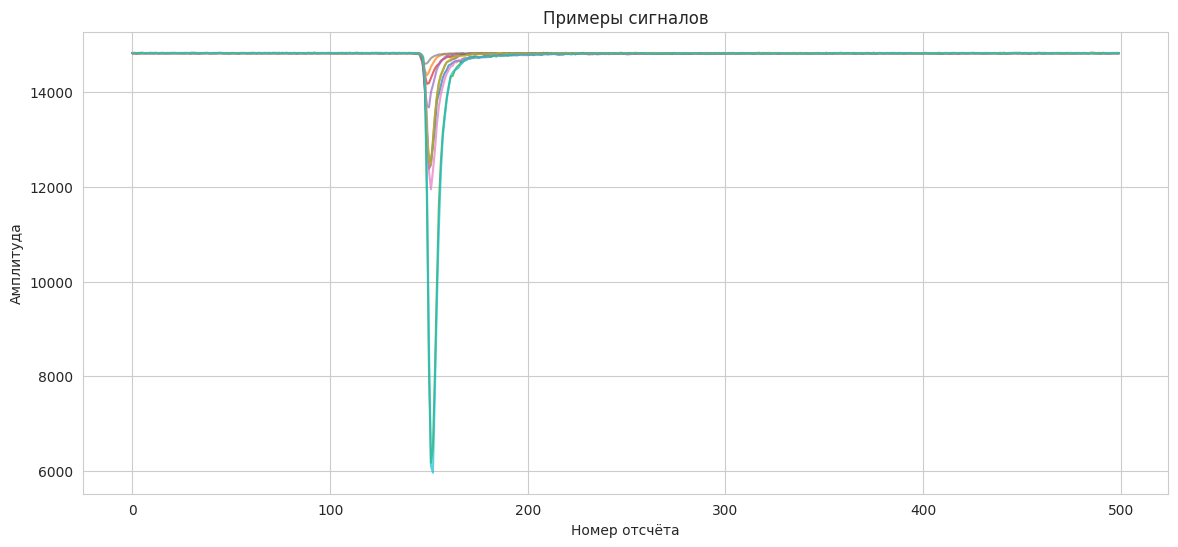

In [92]:
signal_columns = df.columns[4:]

plt.figure(figsize=(14, 6))

sample_idx = np.random.choice(
    df.index,
    size=10,
    replace=False
)

for idx in sample_idx:

    plt.plot(
        df.loc[idx, signal_columns].values,
        alpha=0.7
    )

plt.title("Примеры сигналов")
plt.xlabel("Номер отсчёта")
plt.ylabel("Амплитуда")

plt.show()

Вывод

Все исследованные сигналы обладают общей физической структурой и содержат характерный импульс с последующим восстановлением до базового уровня.

При этом наблюдаются заметные различия в глубине импульса и скорости восстановления сигнала.

Полученные различия позволяют предположить существование нескольких типов событий и указывают на возможность успешной кластеризации сигналов по их форме.

Особый интерес представляют характеристики импульса, которые будут использованы на этапе Feature Engineering.

### Средняя форма сигнала

Рассчитаем усреднённую форму сигнала по всей выборке.

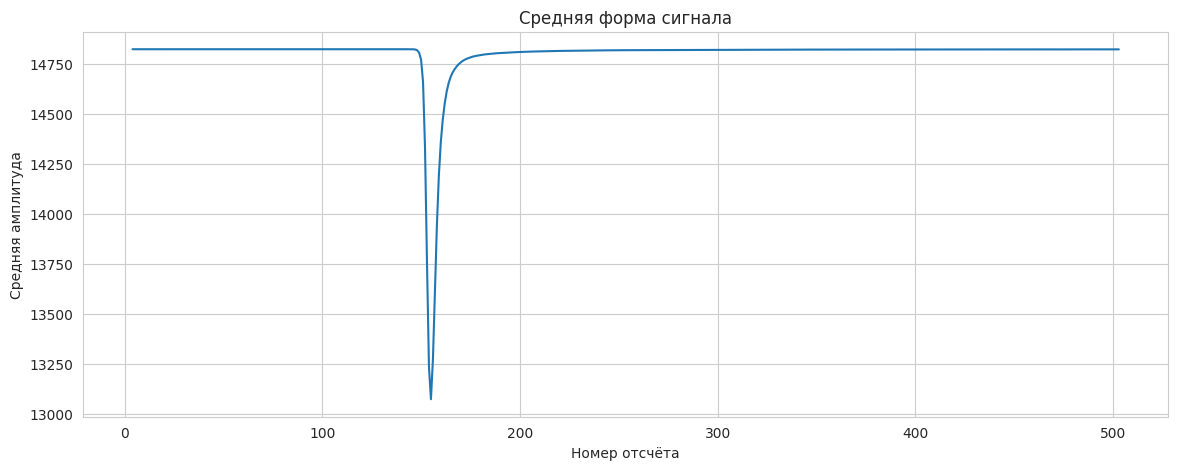

In [93]:
mean_signal = (
    df[signal_columns]
    .mean(axis=0)
)

plt.figure(figsize=(14, 5))

plt.plot(mean_signal)

plt.title("Средняя форма сигнала")
plt.xlabel("Номер отсчёта")
plt.ylabel("Средняя амплитуда")

plt.show()

Вывод

Средняя форма сигнала демонстрирует наличие чётко выраженного импульса, возникающего примерно в одной и той же временной области для большинства наблюдений.

Это свидетельствует о корректной синхронизации сигналов и позволяет сравнивать их между собой без дополнительного выравнивания по времени.

Основные различия между объектами, вероятно, связаны не с положением импульса, а с его амплитудными и временными характеристиками.

### Стандартное отклонение по отсчётам сигнала

Изучим изменчивость сигналов на различных временных участках.

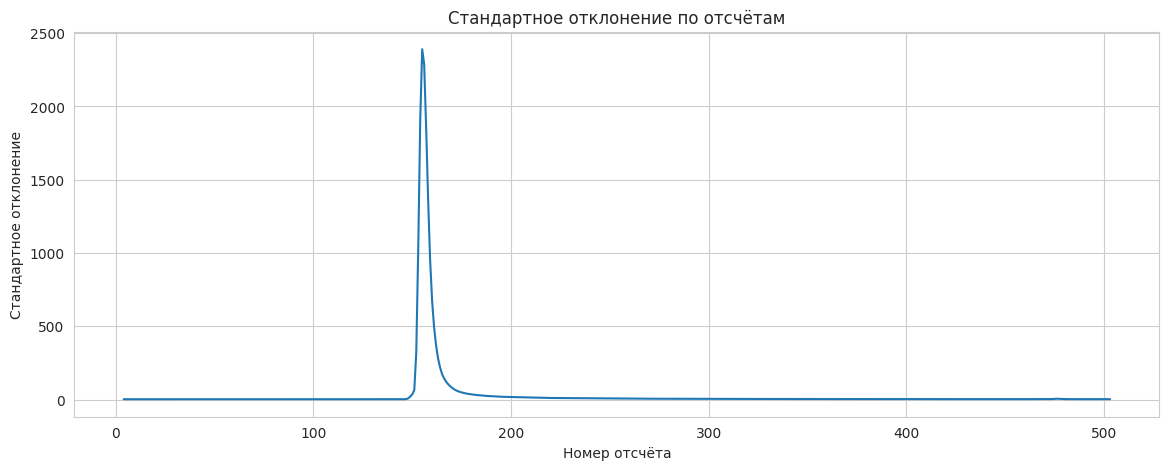

In [94]:
signal_std = (
    df[signal_columns]
    .std(axis=0)
)

plt.figure(figsize=(14, 5))

plt.plot(signal_std)

plt.title("Стандартное отклонение по отсчётам")
plt.xlabel("Номер отсчёта")
plt.ylabel("Стандартное отклонение")

plt.show()

Вывод

Максимальная изменчивость сигналов наблюдается в области формирования импульса.

До возникновения импульса и после восстановления сигналы практически совпадают между собой.

Следовательно, наибольшая информация для последующей кластеризации сосредоточена в центральной части сигнала, где формируется отклик детектора на зарегистрированное событие.

Данный результат подтверждает целесообразность извлечения признаков, характеризующих форму импульса.

### Корреляционный анализ

Из-за высокой размерности построение полной корреляционной матрицы нецелесообразно.

Рассмотрим первые 30 признаков.

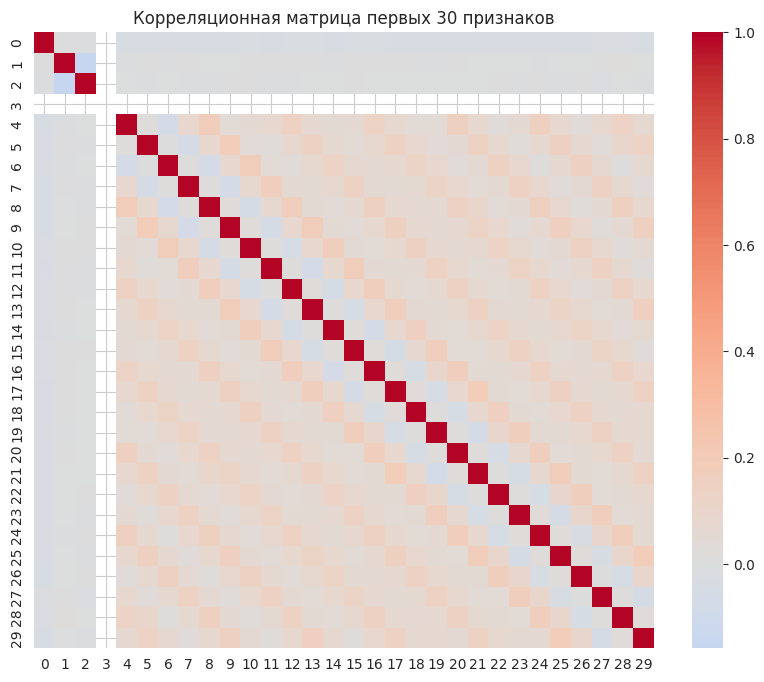

In [95]:
corr_matrix = (
    df.iloc[:, :30]
    .corr()
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title(
    "Корреляционная матрица первых 30 признаков"
)

plt.show()

## Вывод по этапу EDA

В ходе разведочного анализа были изучены структура, качество и физические особенности сигналов сцинтилляционного детектора.

Основные результаты анализа:

- пропуски и дубликаты в данных отсутствуют;
- обнаружены признаки с нулевой дисперсией, не несущие полезной информации;
- все сигналы имеют схожую базовую структуру с выраженным импульсом;
- различия между сигналами проявляются преимущественно в глубине импульса и скорости восстановления;
- максимальная вариативность наблюдается в области импульса;
- между соседними отсчётами присутствуют корреляционные зависимости.

Полученные результаты позволяют сделать вывод о необходимости дальнейшей предобработки данных, удаления неинформативных признаков, масштабирования и извлечения физических характеристик сигнала.

Особое внимание на следующих этапах будет уделено анализу формы импульса как основному источнику информации для кластеризации.

## Шаг 4. Предобработка данных

На этапе EDA было установлено, что данные не содержат пропусков и дубликатов, однако в наборе присутствуют признаки с нулевой дисперсией.

Также было выявлено, что основная часть признаков представляет собой временные отсчёты формы сигнала, а первые несколько столбцов похожи на служебные параметры.

На данном этапе выполним:

- разделение служебных признаков и формы сигнала;
- удаление константных признаков;
- проверку низковариативных признаков;
- масштабирование данных;
- подготовку признакового пространства для дальнейшего снижения размерности и кластеризации.

In [96]:
service_columns = df.columns[:4]
signal_columns = df.columns[4:]

service_df = df[service_columns].copy()
signals_df = df[signal_columns].copy()

print(f"Служебные признаки: {service_df.shape}")
print(f"Отсчёты сигнала: {signals_df.shape}")

Служебные признаки: (23479, 4)
Отсчёты сигнала: (23479, 500)


### Поиск константных признаков

Константные признаки принимают одно и то же значение для всех объектов.

Такие признаки не помогают алгоритмам кластеризации, так как не содержат информации для разделения объектов.

In [97]:
feature_variance = df.var(axis=0)

constant_columns = feature_variance[
    feature_variance == 0
].index.tolist()

print(f"Количество константных признаков: {len(constant_columns)}")
print(f"Константные признаки: {constant_columns}")

Количество константных признаков: 0
Константные признаки: []


### Удаление константных признаков

Удалим признаки с нулевой дисперсией и сохраним очищенную версию датасета.

In [98]:
df_clean = df.drop(columns=constant_columns)

print(f"Размер исходного датасета: {df.shape}")
print(f"Размер после удаления константных признаков: {df_clean.shape}")

Размер исходного датасета: (23479, 504)
Размер после удаления константных признаков: (23479, 504)


### Проверка признаков с низкой вариативностью

Помимо полностью константных признаков, в данных могут быть признаки с очень низкой вариативностью.

Они также могут быть малоинформативны, поэтому дополнительно оценим распределение дисперсий.

In [99]:
clean_variance = df_clean.var(axis=0)

variance_summary = clean_variance.describe()

variance_summary

,0
count,5.040000e+02
mean,6.481472e+18
std,1.455087e+20
min,3.231312e-27
25%,8.066703e+00
50%,1.537642e+01
75%,3.981246e+01
max,3.266662e+21


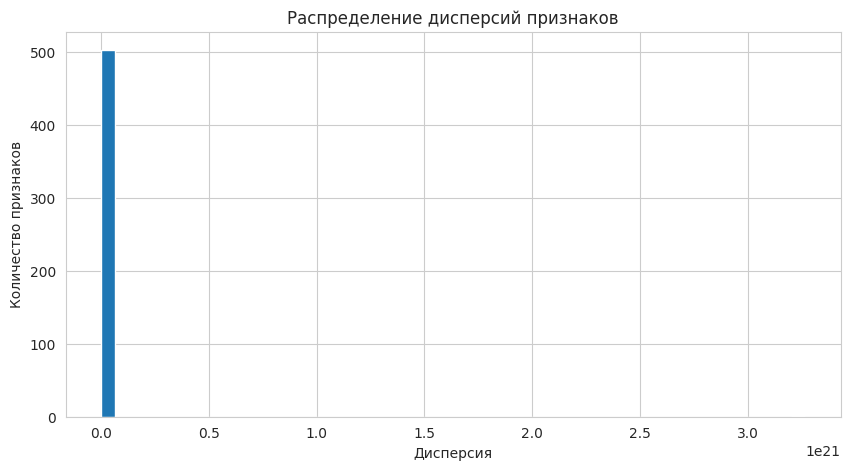

In [100]:
plt.figure(figsize=(10, 5))

plt.hist(
    clean_variance,
    bins=50
)

plt.title("Распределение дисперсий признаков")
plt.xlabel("Дисперсия")
plt.ylabel("Количество признаков")

plt.show()

### Масштабирование признаков

Большинство алгоритмов кластеризации чувствительны к масштабу признаков, так как используют расстояния между объектами.

Для масштабирования используем `RobustScaler`, так как он устойчивее к выбросам, чем стандартное масштабирование.

In [101]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

x_scaled = scaler.fit_transform(df_clean)

x_scaled_df = pd.DataFrame(
    x_scaled,
    columns=df_clean.columns,
    index=df_clean.index
)

print(f"Размер масштабированной матрицы: {x_scaled_df.shape}")

Размер масштабированной матрицы: (23479, 504)


In [102]:
x_scaled_df.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
0,23479.0,-0.004875,0.579200,-1.028108,-0.505602,0.0,0.494398,0.998751
1,23479.0,0.061116,0.591845,-0.836777,-0.451446,0.0,0.548554,1.227273
2,23479.0,0.477784,1.122653,-0.386635,-0.257757,0.0,0.742243,7.632458
3,23479.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
4,23479.0,-0.009228,0.935295,-3.666667,-0.666667,0.0,0.333333,3.666667
5,23479.0,-0.013842,0.944505,-3.666667,-0.666667,0.0,0.333333,4.000000
6,23479.0,-0.007496,0.710189,-2.750000,-0.500000,0.0,0.500000,2.750000
7,23479.0,-0.002502,0.713017,-3.000000,-0.500000,0.0,0.500000,3.000000
8,23479.0,0.000990,0.708353,-2.750000,-0.500000,0.0,0.500000,2.750000
9,23479.0,-0.007127,0.945424,-3.666667,-0.666667,0.0,0.333333,4.000000


Признаки были приведены к сопоставимому масштабу.

Это необходимо для корректной работы алгоритмов, основанных на расстояниях, таких как K-Means, Agglomerative Clustering и DBSCAN.

На следующих этапах масштабированная матрица будет использоваться для PCA и базовой кластеризации.

### Подготовка отдельной матрицы сигналов

Так как основная физическая информация содержится в форме импульса, дополнительно подготовим очищенную матрицу только с отсчётами сигнала.

In [103]:
signals_clean_df = signals_df.copy()

signal_scaler = RobustScaler()

signals_scaled = signal_scaler.fit_transform(signals_clean_df)

signals_scaled_df = pd.DataFrame(
    signals_scaled,
    columns=signals_clean_df.columns,
    index=signals_clean_df.index
)

print(f"Размер масштабированной матрицы сигналов: {signals_scaled_df.shape}")

Размер масштабированной матрицы сигналов: (23479, 500)


## Вывод по шагу 4. Предобработка данных

На этапе предобработки данные были разделены на служебные признаки и отсчёты формы сигнала.

Получено:

- служебные признаки: 4 столбца;
- отсчёты формы сигнала: 500 столбцов;
- итоговая размерность данных: 23 479 объектов и 504 признака.

Пропуски и дубликаты ранее не были обнаружены. При анализе дисперсий видно, что один из признаков фактически имеет почти нулевую вариативность, однако из-за численного представления он не был автоматически определён как строго константный. Особенно это заметно по `service_3`, который принимает значение 500 для всех объектов.

Распределение дисперсий сильно смещено из-за служебного признака `service_0`, имеющего очень большой масштаб. Это подтверждает необходимость масштабирования признаков перед применением PCA и алгоритмов кластеризации.

После масштабирования данные приведены к сопоставимому масштабу, что особенно важно для методов, основанных на расстояниях: K-Means, Agglomerative Clustering, DBSCAN.

## Шаг 5. Feature Engineering

Feature Engineering является важным этапом данной задачи, так как исходные 500 отсчётов сигнала содержат временную форму импульса, но не дают напрямую физических характеристик события.

На основе формы сигнала извлечём дополнительные признаки:

- базовый уровень сигнала;
- минимальное значение импульса;
- амплитуду;
- площадь импульса;
- энергию;
- положение минимума;
- ширину импульса;
- время восстановления;
- статистические характеристики формы сигнала.

Эти признаки помогут алгоритмам кластеризации лучше различать типы сигналов.

### Расчёт базового уровня сигнала

Базовый уровень будем оценивать по первым отсчётам сигнала до появления импульса.

На графиках EDA было видно, что до импульса сигнал находится около стабильного уровня.

In [104]:
baseline_window = 100

baseline = signals_df.iloc[:, :baseline_window].mean(axis=1)

baseline.head()

,0
0,14821.13
1,14822.47
2,14821.92
3,14822.76
4,14821.43


### Преобразование сигнала к положительному импульсу

В исходных данных импульс выглядит как резкое падение амплитуды.

Для удобства анализа преобразуем сигнал так, чтобы импульс стал положительным:

`pulse = baseline - signal`

In [105]:
pulse_df = signals_df.rsub(baseline, axis=0)

pulse_df.head()

,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499,500,501,502,503
0,1.13,-1.87,-2.87,-0.87,3.13,1.13,-2.87,-0.87,1.13,1.13,1.13,-0.87,-2.87,1.13,-6.87,2.13,-0.87,-0.87,1.13,-0.87,1.13,2.13,1.13,0.13,6.13,-8.87,-2.87,-3.87,1.13,1.13,-2.87,-0.87,4.13,-3.87,1.13,7.13,-0.87,-1.87,-2.87,1.13,1.13,-1.87,-0.87,4.13,-2.87,-4.87,-1.87,-0.87,3.13,-0.87,1.13,4.13,1.13,0.13,-0.87,1.13,3.13,1.13,1.13,-3.87,3.13,2.13,-2.87,-0.87,3.13,1.13,-5.87,-4.87,-2.87,2.13,1.13,-0.87,1.13,1.13,-0.87,-3.87,-0.87,0.13,4.13,-0.87,2.13,0.13,-1.87,0.13,4.13,1.13,-5.87,1.13,1.13,-1.87,1.13,6.13,1.13,-0.87,1.13,-2.87,4.13,3.13,2.13,-0.87,2.13,3.13,-5.87,1.13,3.13,1.13,2.13,3.13,1.13,-2.87,-0.87,1.13,4.13,-0.87,1.13,4.13,-2.87,-0.87,-1.87,-2.87,1.13,-3.87,3.13,-1.87,4.13,1.13,-2.87,-2.87,6.13,1.13,1.13,-0.87,4.13,-0.87,1.13,1.13,1.13,-0.87,1.13,2.13,3.13,-1.87,3.13,3.13,1.13,7.13,58.13,258.13,443.13,530.13,443.13,361.13,289.13,214.13,191.13,140.13,89.13,80.13,73.13,65.13,49.13,42.13,31.13,29.13,22.13,20.13,22.13,24.13,29.13,18.13,23.13,27.13,27.13,7.13,13.13,10.13,11.13,14.13,6.13,11.13,14.13,20.13,17.13,17.13,20.13,20.13,11.13,15.13,30.13,8.13,22.13,19.13,17.13,10.13,9.13,18.13,18.13,9.13,5.13,2.13,9.13,12.13,4.13,4.13,6.13,4.13,1.13,4.13,9.13,5.13,2.13,5.13,6.13,-0.87,15.13,4.13,12.13,8.13,11.13,8.13,9.13,2.13,9.13,6.13,9.13,-1.87,11.13,11.13,2.13,2.13,-0.87,8.13,5.13,1.13,5.13,4.13,1.13,2.13,4.13,0.13,1.13,-4.87,2.13,1.13,1.13,-4.87,2.13,0.13,9.13,1.13,4.13,8.13,9.13,6.13,6.13,7.13,4.13,4.13,4.13,6.13,7.13,1.13,6.13,8.13,11.13,1.13,-0.87,0.13,3.13,3.13,2.13,1.13,9.13,3.13,1.13,5.13,3.13,2.13,4.13,2.13,1.13,5.13,4.13,5.13,2.13,2.13,3.13,3.13,4.13,1.13,3.13,-2.87,-1.87,8.13,4.13,3.13,6.13,-3.87,2.13,-5.87,3.13,6.13,1.13,-1.87,6.13,-0.87,-5.87,-0.87,3.13,3.13,3.13,-0.87,9.13,-8.87,2.13,4.13,-1.87,-6.87,-2.87,11.13,4.13,-5.87,-1.87,7.13,1.13,0.13,1.13,5.13,3.13,-6.87,3.13,-0.87,2.13,-1.87,4.13,5.13,-2.87,-0.87,-1.87,3.13,-0.87,-3.87,1.13,-1.87,3.13,-0.87,1.13,1.13,3.13,-1.87,2.13,2.13,4.13,-1.87,-0.87,0.13,6.13,9.13,1.13,7.13,5.13,-3.87,3.13,5.13,1.13,0.13,1.13,-0.87,1.13,-6.87,4.13,9.13,1.13,-4.87,1.13,3.13,4.13,-3.87,3.13,-0.87,1.13,-1.87,1.13,1.13,2.13,3.13,-1.

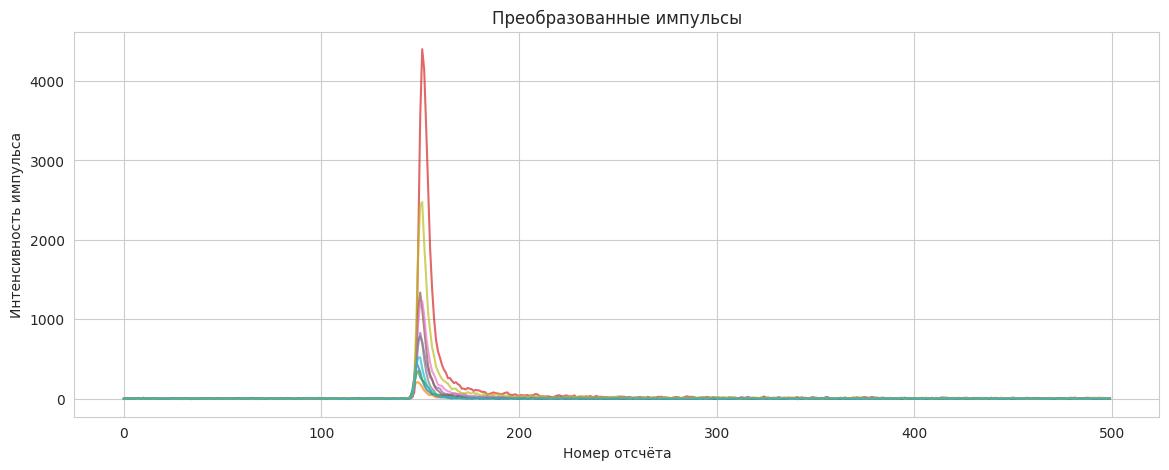

In [106]:
plt.figure(figsize=(14, 5))

for idx in np.random.choice(df.index, size=10, replace=False):
    plt.plot(
        pulse_df.loc[idx].values,
        alpha=0.7
    )

plt.title("Преобразованные импульсы")
plt.xlabel("Номер отсчёта")
plt.ylabel("Интенсивность импульса")

plt.show()

Инсайт

После преобразования импульсы стали положительными.

Это упрощает дальнейший расчёт физических признаков: амплитуды, площади и энергии сигнала.

In [107]:
features_df = pd.DataFrame(index=df.index)

features_df["baseline"] = baseline
features_df["min_signal"] = signals_df.min(axis=1)
features_df["max_pulse"] = pulse_df.max(axis=1)
features_df["argmax_pulse"] = pulse_df.values.argmax(axis=1)

features_df.head()

,baseline,min_signal,max_pulse,argmax_pulse
0,14821.13,14291,530.13,149
1,14822.47,12921,1901.47,150
2,14821.92,12264,2557.92,151
3,14822.76,14258,564.76,149
4,14821.43,13028,1793.43,150


### Расчёт площади и энергии импульса

Площадь под импульсом можно интерпретировать как суммарный отклик детектора.

Энергия сигнала дополнительно усиливает вклад крупных отклонений.

In [108]:
positive_pulse_df = pulse_df.clip(lower=0)

features_df["pulse_area"] = positive_pulse_df.sum(axis=1)
features_df["pulse_energy"] = (positive_pulse_df ** 2).sum(axis=1)

features_df[["pulse_area", "pulse_energy"]].head()

,pulse_area,pulse_energy
0,4983.28,1.106661e+06
1,12655.80,1.360624e+07
2,17264.16,2.591893e+07
3,5015.84,1.295659e+06
4,12013.03,1.249674e+07


### Расчёт ширины импульса

Ширина импульса показывает, как долго сигнал остаётся заметно отличным от базового уровня.

Для оценки ширины используем порог в 10% от максимальной амплитуды импульса.

In [109]:
threshold_ratio = 0.10

thresholds = features_df["max_pulse"] * threshold_ratio

pulse_widths = []

for idx in pulse_df.index:
    pulse_values = positive_pulse_df.loc[idx].values
    threshold = thresholds.loc[idx]

    width = np.sum(pulse_values > threshold)
    pulse_widths.append(width)

features_df["pulse_width"] = pulse_widths

features_df[["max_pulse", "pulse_width"]].head()

,max_pulse,pulse_width
0,530.13,14
1,1901.47,11
2,2557.92,12
3,564.76,12
4,1793.43,12


### Расчёт времени восстановления

Время восстановления — это количество отсчётов от максимума импульса до момента, когда сигнал возвращается почти к базовому уровню.

Для оценки используем порог 5% от максимальной амплитуды.

In [110]:
recovery_ratio = 0.05
recovery_times = []

for idx in pulse_df.index:
    pulse_values = positive_pulse_df.loc[idx].values
    max_position = features_df.loc[idx, "argmax_pulse"]
    max_value = features_df.loc[idx, "max_pulse"]

    recovery_threshold = max_value * recovery_ratio
    tail_values = pulse_values[max_position:]

    recovered_positions = np.where(
        tail_values <= recovery_threshold
    )[0]

    if len(recovered_positions) > 0:
        recovery_time = recovered_positions[0]
    else:
        recovery_time = len(tail_values)

    recovery_times.append(recovery_time)

features_df["recovery_time"] = recovery_times

features_df[["argmax_pulse", "recovery_time"]].head()

,argmax_pulse,recovery_time
0,149,15
1,150,11
2,151,13
3,149,12
4,150,11


Инсайт

Время восстановления является физически интерпретируемым признаком.

Если разные типы частиц формируют импульсы с различной скоростью затухания, этот показатель может значительно повысить качество кластеризации.

### Статистические признаки формы импульса

Дополнительно рассчитаем статистические характеристики формы сигнала:

- среднее значение;
- стандартное отклонение;
- медиану;
- асимметрию;
- эксцесс.

Эти признаки помогут описать форму импульса более полно.

In [111]:
from scipy.stats import kurtosis, skew

features_df["pulse_mean"] = positive_pulse_df.mean(axis=1)
features_df["pulse_std"] = positive_pulse_df.std(axis=1)
features_df["pulse_median"] = positive_pulse_df.median(axis=1)

features_df["pulse_skew"] = skew(
    positive_pulse_df,
    axis=1
)

features_df["pulse_kurtosis"] = kurtosis(
    positive_pulse_df,
    axis=1
)

features_df.head()

,baseline,min_signal,max_pulse,argmax_pulse,pulse_area,pulse_energy,pulse_width,recovery_time,pulse_mean,pulse_std,pulse_median,pulse_skew,pulse_kurtosis
0,14821.13,14291,530.13,149,4983.28,1.106661e+06,14,15,9.96656,46.024183,1.13,8.262674,73.928209
1,14822.47,12921,1901.47,150,12655.80,1.360624e+07,11,11,25.31160,163.171872,2.47,8.942117,85.015075
2,14821.92,12264,2557.92,151,17264.16,2.591893e+07,12,13,34.52832,225.271278,1.92,8.873357,83.508607
3,14822.76,14258,564.76,149,5015.84,1.295659e+06,12,12,10.03168,49.956721,1.76,8.454615,76.946673
4,14821.43,13028,1793.43,150,12013.03,1.249674e+07,12,11,24.02606,156.413441,1.43,8.869941,83.154322


### Добавление служебных признаков

Добавим информативные служебные признаки, кроме константных.

Это позволит проверить, помогают ли параметры, записанные в первых столбцах, улучшить разделение сигналов.

In [112]:
informative_service_columns = [
    column for column in service_columns
    if column not in constant_columns
]

for column in informative_service_columns:
    features_df[f"service_{column}"] = df[column]

features_df.head()

,baseline,min_signal,max_pulse,argmax_pulse,pulse_area,pulse_energy,pulse_width,recovery_time,pulse_mean,pulse_std,pulse_median,pulse_skew,pulse_kurtosis,service_0,service_1,service_2,service_3
0,14821.13,14291,530.13,149,4983.28,1.106661e+06,14,15,9.96656,46.024183,1.13,8.262674,73.928209,2890276,357,113,500
1,14822.47,12921,1901.47,150,12655.80,1.360624e+07,11,11,25.31160,163.171872,2.47,8.942117,85.015075,4928764,740,359,500
2,14821.92,12264,2557.92,151,17264.16,2.591893e+07,12,13,34.52832,225.271278,1.92,8.873357,83.508607,9630204,162,499,500
3,14822.76,14258,564.76,149,5015.84,1.295659e+06,12,12,10.03168,49.956721,1.76,8.454615,76.946673,15798632,841,123,500
4,14821.43,13028,1793.43,150,12013.03,1.249674e+07,12,11,24.02606,156.413441,1.43,8.869941,83.154322,20637296,412,348,500


### Проверка полученного набора признаков

Проверим размерность нового набора признаков, наличие пропусков и основные статистики.

In [113]:
print(f"Размер features_df: {features_df.shape}")
print(f"Количество пропусков: {features_df.isna().sum().sum()}")

features_df.describe().T

Размер features_df: (23479, 17)
Количество пропусков: 0


,count,mean,std,min,25%,50%,75%,max
baseline,23479.0,1.482297e+04,8.204018e-01,1.481862e+04,1.482242e+04,1.482296e+04,1.482352e+04,1.482634e+04
min_signal,23479.0,1.298786e+04,2.389309e+03,0.000000e+00,1.250800e+04,1.401000e+04,1.451500e+04,1.471900e+04
max_pulse,23479.0,1.835103e+03,2.389301e+03,1.042300e+02,3.082200e+02,8.127200e+02,2.315270e+03,1.482482e+04
argmax_pulse,23479.0,1.496286e+02,2.489996e+00,1.450000e+02,1.490000e+02,1.500000e+02,1.510000e+02,4.720000e+02
pulse_area,23479.0,1.351527e+04,1.602687e+04,1.087400e+03,2.884815e+03,6.628800e+03,1.761989e+04,1.132773e+05
pulse_energy,23479.0,3.569897e+07,8.928643e+07,5.133089e+04,3.938410e+05,2.674202e+06,2.153665e+07,1.125854e+09
pulse_width,23479.0,1.339861e+01,2.701102e+00,6.000000e+00,1.100000e+01,1.300000e+01,1.500000e+01,2.900000e+01
recovery_time,23479.0,1.434584e+01,3.763347e+00,7.000000e+00,1.100000e+01,1.400000e+01,1.700000e+01,3.000000e+01
pulse_mean,23479.0,2.703054e+01,3.205373e+01,2.174800e+00,5.769630e+00,1.325760e+01,3.523977e+01,2.265545e+02
pulse_std,23479.0,1.615199e+02,2.090278e+02,9.869371e+00,2.750227e+01,7.197936e+01,2.045449e+02,1.484854e+03


In [114]:
features_df.head()

,baseline,min_signal,max_pulse,argmax_pulse,pulse_area,pulse_energy,pulse_width,recovery_time,pulse_mean,pulse_std,pulse_median,pulse_skew,pulse_kurtosis,service_0,service_1,service_2,service_3
0,14821.13,14291,530.13,149,4983.28,1.106661e+06,14,15,9.96656,46.024183,1.13,8.262674,73.928209,2890276,357,113,500
1,14822.47,12921,1901.47,150,12655.80,1.360624e+07,11,11,25.31160,163.171872,2.47,8.942117,85.015075,4928764,740,359,500
2,14821.92,12264,2557.92,151,17264.16,2.591893e+07,12,13,34.52832,225.271278,1.92,8.873357,83.508607,9630204,162,499,500
3,14822.76,14258,564.76,149,5015.84,1.295659e+06,12,12,10.03168,49.956721,1.76,8.454615,76.946673,15798632,841,123,500
4,14821.43,13028,1793.43,150,12013.03,1.249674e+07,12,11,24.02606,156.413441,1.43,8.869941,83.154322,20637296,412,348,500


### Визуализация инженерных признаков

Рассмотрим распределения ключевых признаков, чтобы оценить их информативность.

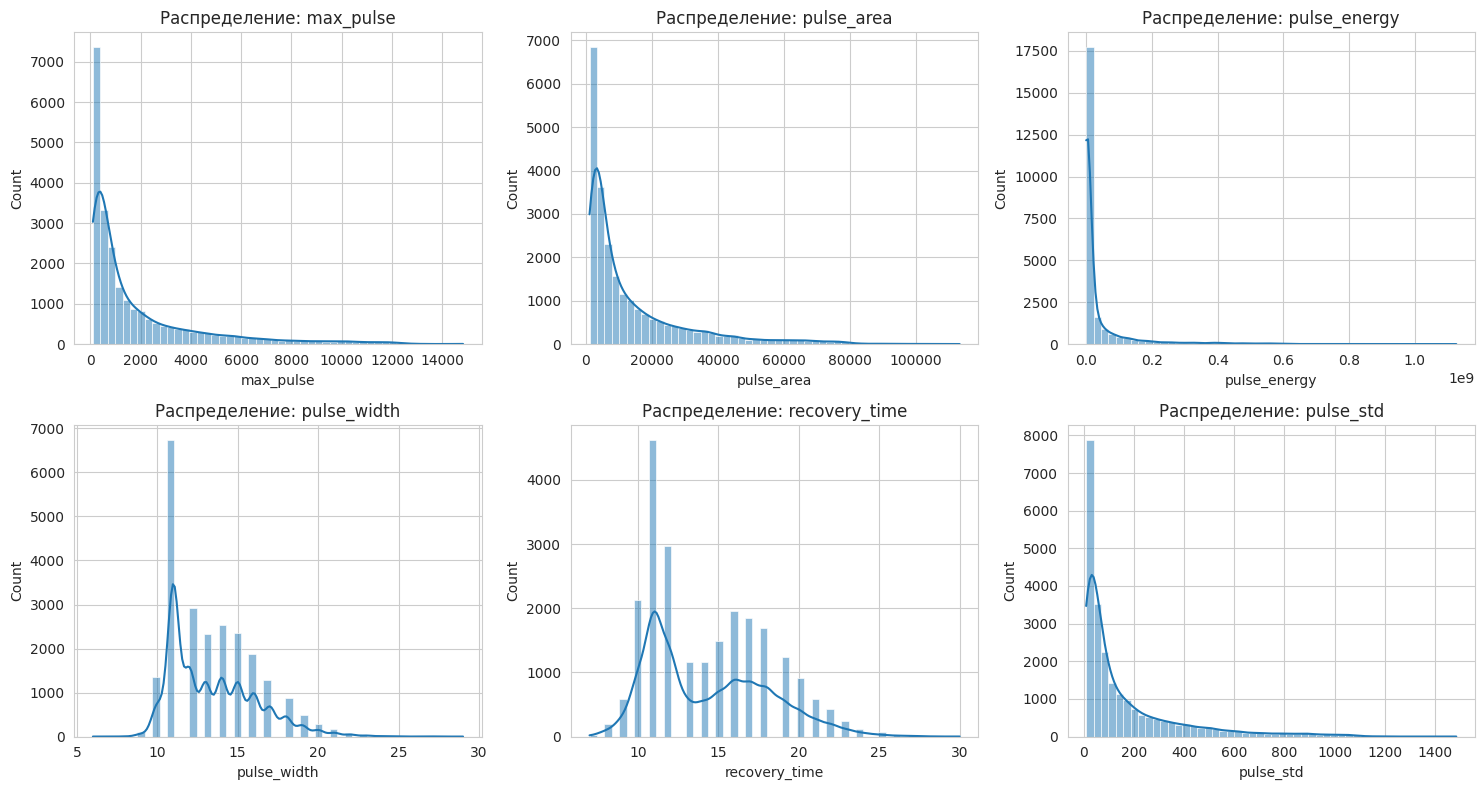

In [115]:
important_features = [
    "max_pulse",
    "pulse_area",
    "pulse_energy",
    "pulse_width",
    "recovery_time",
    "pulse_std"
]

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(15, 8)
)

for idx, feature in enumerate(important_features):
    row = idx // 3
    col = idx % 3

    sns.histplot(
        data=features_df,
        x=feature,
        bins=50,
        kde=True,
        ax=axes[row, col]
    )

    axes[row, col].set_title(f"Распределение: {feature}")

plt.tight_layout()
plt.show()

Инсайт

Если распределения признаков имеют несколько пиков или выраженную асимметрию, это может указывать на наличие нескольких групп сигналов.

Такие признаки потенциально полезны для кластеризации.

### Корреляция инженерных признаков

Проверим взаимосвязи между полученными признаками.

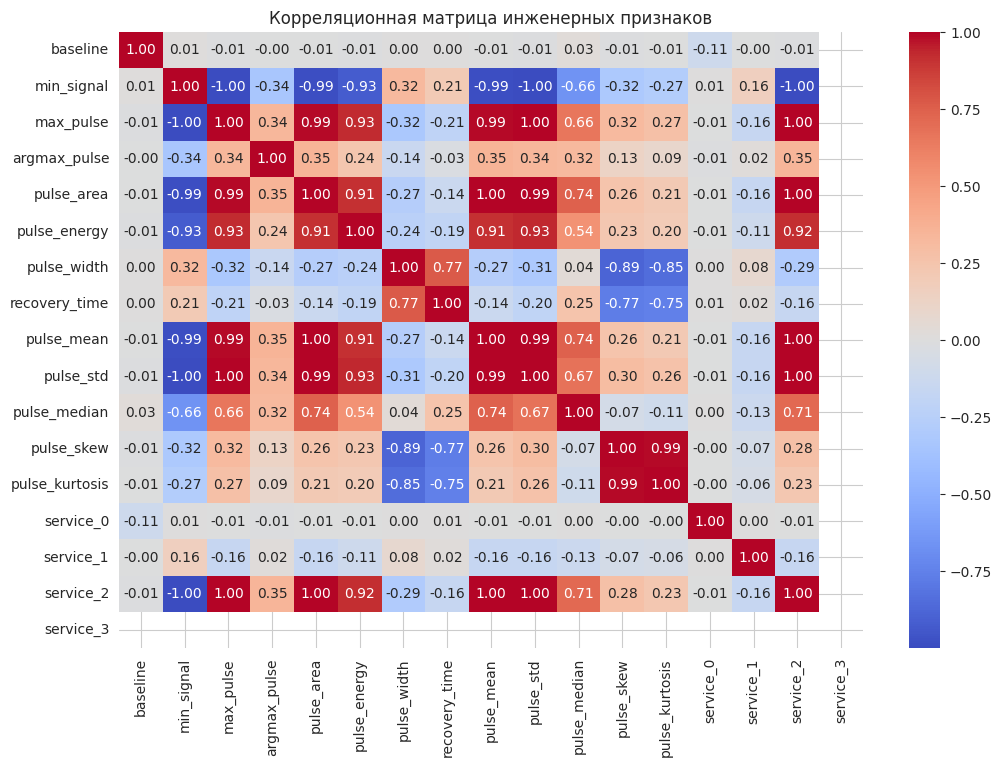

In [116]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    features_df.corr(),
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)

plt.title("Корреляционная матрица инженерных признаков")

plt.show()

Вывод

Корреляционная матрица показывает взаимосвязи между инженерными признаками.

Сильные корреляции ожидаемы, например, между амплитудой, площадью и энергией импульса.

При дальнейшем анализе это можно учитывать при снижении размерности и выборе признакового пространства.

In [117]:
feature_scaler = RobustScaler()

features_scaled = feature_scaler.fit_transform(features_df)

features_scaled_df = pd.DataFrame(
    features_scaled,
    columns=features_df.columns,
    index=features_df.index
)

features_scaled_df.head()

,baseline,min_signal,max_pulse,argmax_pulse,pulse_area,pulse_energy,pulse_width,recovery_time,pulse_mean,pulse_std,pulse_median,pulse_skew,pulse_kurtosis,service_0,service_1,service_2,service_3
0,-1.663636,0.140010,-0.140799,-0.5,-0.111674,-0.074141,0.25,0.166667,-0.111674,-0.146604,-0.106599,-0.330400,-0.313960,-1.028108,-0.467975,-0.140811,0.0
1,-0.445455,-0.542601,0.542463,0.0,0.409024,0.517057,-0.50,-0.500000,0.409024,0.515088,0.573604,0.438195,0.443737,-1.028087,-0.072314,0.446301,0.0
2,-0.945455,-0.869955,0.869535,0.5,0.721772,1.099416,-0.25,-0.166667,0.721772,0.865848,0.294416,0.360413,0.340782,-1.028039,-0.669421,0.780430,0.0
3,-0.181818,0.123568,-0.123545,-0.5,-0.109464,-0.065202,-0.25,-0.333333,-0.109464,-0.124392,0.213198,-0.113273,-0.107672,-1.027977,0.032025,-0.116945,0.0
4,-1.390909,-0.489287,0.488633,0.0,0.365402,0.464581,-0.25,-0.500000,0.365402,0.476914,0.045685,0.356549,0.316569,-1.027928,-0.411157,0.420048,0.0


### Вывод по этапу Feature Engineering

На этапе Feature Engineering были извлечены физически интерпретируемые признаки формы сигнала:

- базовый уровень сигнала;
- минимальное значение сигнала;
- амплитуда импульса;
- положение максимума импульса;
- площадь импульса;
- энергия импульса;
- ширина импульса;
- время восстановления;
- статистические характеристики формы импульса;
- служебные признаки.

График преобразованных импульсов показывает, что после вычитания сигнала из baseline импульсы стали положительными. Это упростило расчёт амплитуды, площади и энергии.

Распределения инженерных признаков имеют выраженную правостороннюю асимметрию. Особенно это заметно для `max_pulse`, `pulse_area`, `pulse_energy` и `pulse_std`. Это может указывать на наличие разных групп сигналов: слабых, средних и сильных событий.

Признаки `pulse_width` и `recovery_time` имеют несколько локальных пиков, что может быть полезно для разделения сигналов по форме и длительности импульса.

Корреляционная матрица показала сильную связь между `max_pulse`, `pulse_area`, `pulse_energy`, `pulse_mean`, `pulse_std` и `service_2`. Это означает, что часть признаков описывает близкие физические свойства сигнала. Поэтому на следующем этапе целесообразно применить PCA для снижения размерности и устранения избыточности.

Отдельно стоит отметить, что `service_3` является константным признаком и должен быть исключён перед обучением моделей.

## Шаг 6. Снижение размерности

После Feature Engineering получен компактный набор признаков, однако часть признаков сильно коррелирует между собой.

Для анализа структуры данных применим метод главных компонент PCA.

PCA позволит:

- уменьшить размерность признакового пространства;
- визуализировать данные в 2D;
- оценить, есть ли естественная кластерная структура;
- подготовить данные для последующей кластеризации.

In [118]:
constant_feature_columns = features_df.columns[
    features_df.nunique() <= 1
].tolist()

print("Константные признаки:", constant_feature_columns)

features_df_clean = features_df.drop(
    columns=constant_feature_columns
)

print(f"Размер до удаления: {features_df.shape}")
print(f"Размер после удаления: {features_df_clean.shape}")

Константные признаки: ['service_3']
Размер до удаления: (23479, 17)
Размер после удаления: (23479, 16)


In [119]:
feature_scaler = RobustScaler()

features_scaled = feature_scaler.fit_transform(features_df_clean)

features_scaled_df = pd.DataFrame(
    features_scaled,
    columns=features_df_clean.columns,
    index=features_df_clean.index
)

features_scaled_df.head()

,baseline,min_signal,max_pulse,argmax_pulse,pulse_area,pulse_energy,pulse_width,recovery_time,pulse_mean,pulse_std,pulse_median,pulse_skew,pulse_kurtosis,service_0,service_1,service_2
0,-1.663636,0.140010,-0.140799,-0.5,-0.111674,-0.074141,0.25,0.166667,-0.111674,-0.146604,-0.106599,-0.330400,-0.313960,-1.028108,-0.467975,-0.140811
1,-0.445455,-0.542601,0.542463,0.0,0.409024,0.517057,-0.50,-0.500000,0.409024,0.515088,0.573604,0.438195,0.443737,-1.028087,-0.072314,0.446301
2,-0.945455,-0.869955,0.869535,0.5,0.721772,1.099416,-0.25,-0.166667,0.721772,0.865848,0.294416,0.360413,0.340782,-1.028039,-0.669421,0.780430
3,-0.181818,0.123568,-0.123545,-0.5,-0.109464,-0.065202,-0.25,-0.333333,-0.109464,-0.124392,0.213198,-0.113273,-0.107672,-1.027977,0.032025,-0.116945
4,-1.390909,-0.489287,0.488633,0.0,0.365402,0.464581,-0.25,-0.500000,0.365402,0.476914,0.045685,0.356549,0.316569,-1.027928,-0.411157,0.420048


In [120]:
pca_full = PCA(random_state=RANDOM_STATE)

features_pca_full = pca_full.fit_transform(features_scaled_df)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

pca_variance_df = pd.DataFrame(
    {
        "component": np.arange(1, len(explained_variance) + 1),
        "explained_variance": explained_variance,
        "cumulative_variance": cumulative_variance
    }
)

pca_variance_df.head(10)

,component,explained_variance,cumulative_variance
0,1,0.821974,0.821974
1,2,0.053728,0.875702
2,3,0.046672,0.922374
3,4,0.026547,0.948921
4,5,0.018392,0.967313
5,6,0.010740,0.978053
6,7,0.010555,0.988608
7,8,0.005465,0.994073
8,9,0.003441,0.997515
9,10,0.002217,0.999731


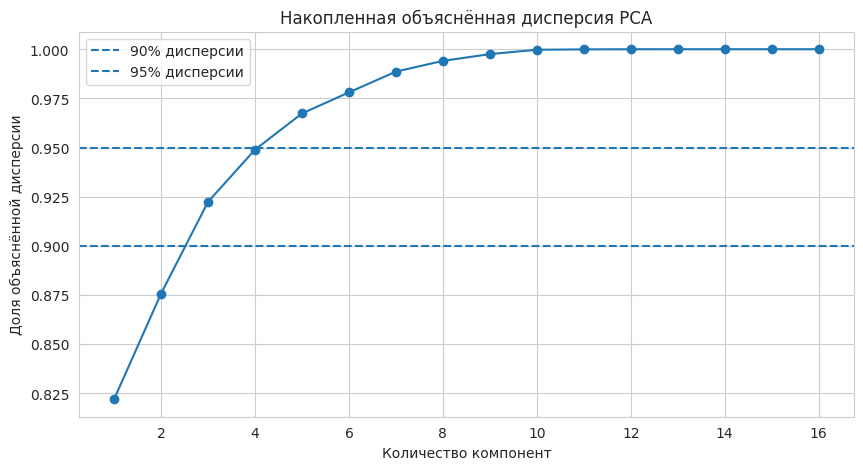

In [121]:
plt.figure(figsize=(10, 5))

plt.plot(
    pca_variance_df["component"],
    pca_variance_df["cumulative_variance"],
    marker="o"
)

plt.axhline(
    y=0.90,
    linestyle="--",
    label="90% дисперсии"
)

plt.axhline(
    y=0.95,
    linestyle="--",
    label="95% дисперсии"
)

plt.title("Накопленная объяснённая дисперсия PCA")
plt.xlabel("Количество компонент")
plt.ylabel("Доля объяснённой дисперсии")
plt.legend()

plt.show()

In [122]:
pca_2d = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

features_pca_2d = pca_2d.fit_transform(features_scaled_df)

pca_2d_df = pd.DataFrame(
    features_pca_2d,
    columns=["PC1", "PC2"],
    index=features_scaled_df.index
)

print(
    "Доля объяснённой дисперсии двумя компонентами:",
    pca_2d.explained_variance_ratio_.sum()
)

pca_2d_df.head()

Доля объяснённой дисперсии двумя компонентами: 0.8757016998182052


,PC1,PC2
0,-2.249173,-0.388687
1,-0.767001,0.772427
2,0.145738,1.149675
3,-2.158533,-0.179075
4,-0.927342,0.599937


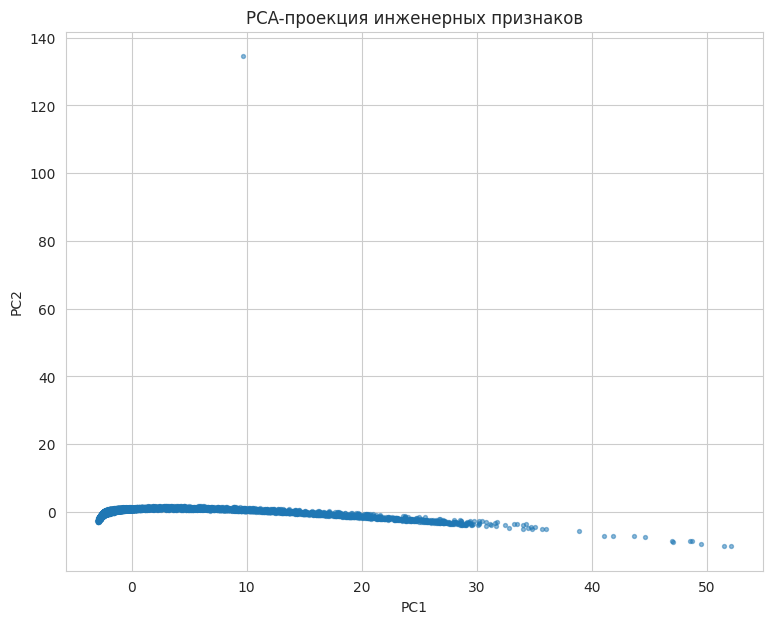

In [123]:
plt.figure(figsize=(9, 7))

plt.scatter(
    pca_2d_df["PC1"],
    pca_2d_df["PC2"],
    s=8,
    alpha=0.5
)

plt.title("PCA-проекция инженерных признаков")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

## Вывод по шагу 6. Снижение размерности

На этапе PCA был удалён константный признак `service_3`, который не несёт информации для кластеризации.

После удаления осталось 16 инженерных признаков.

PCA показал, что первая главная компонента объясняет около 82.2% дисперсии, а первые две компоненты — около 87.6%. Для объяснения более 95% дисперсии достаточно примерно 5 компонент.

Это подтверждает наличие сильной избыточности между инженерными признаками. Такой результат согласуется с корреляционной матрицей, где признаки амплитуды, площади, энергии и стандартного отклонения импульса были сильно связаны между собой.

PCA-визуализация показывает вытянутую структуру данных. Большинство объектов расположены вдоль одной основной оси, что может отражать изменение силы или энергии зарегистрированного события.

Также заметны отдельные выбросы, особенно точка с высоким значением PC2. Это может соответствовать аномальному или нестандартному сигналу, что важно для задачи, где один из кластеров должен описывать неопределённые или аномальные события.

## Шаг 7. Базовые модели кластеризации

Согласно условию задачи, необходимо разделить сигналы на три кластера:

- два кластера соответствуют разным типам частиц;
- третий кластер соответствует аномальным или неопределённым сигналам.

Начнём с базовых алгоритмов:

- K-Means;
- Gaussian Mixture Model.

Для оценки качества будем использовать внутренние метрики кластеризации:

- Silhouette Score;
- Davies-Bouldin Index;
- Calinski-Harabasz Index.

Так как истинные метки классов отсутствуют, эти метрики позволяют сравнивать модели между собой.

In [124]:
def evaluate_clustering(data, labels, model_name):
    """Возвращает основные метрики качества кластеризации."""

    metrics = {
        "model": model_name,
        "n_clusters": len(np.unique(labels)),
        "silhouette": silhouette_score(data, labels),
        "davies_bouldin": davies_bouldin_score(data, labels),
        "calinski_harabasz": calinski_harabasz_score(data, labels)
    }

    return metrics

In [125]:
kmeans = KMeans(
    n_clusters=3,
    init="k-means++",
    n_init=20,
    random_state=RANDOM_STATE
)

kmeans_labels = kmeans.fit_predict(features_scaled_df)

kmeans_metrics = evaluate_clustering(
    data=features_scaled_df,
    labels=kmeans_labels,
    model_name="KMeans_features"
)

kmeans_metrics

{'model': 'KMeans_features',
 'n_clusters': 3,
 'silhouette': np.float64(0.5693406335508542),
 'davies_bouldin': np.float64(0.6624569477624739),
 'calinski_harabasz': np.float64(31801.364903294972)}

In [126]:
kmeans_cluster_counts = pd.Series(
    kmeans_labels
).value_counts().sort_index()

kmeans_cluster_counts

,count
0,19363
1,879
2,3237


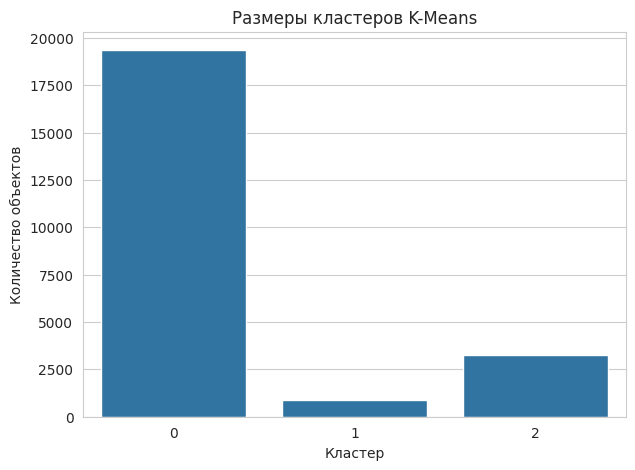

In [127]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=kmeans_cluster_counts.index,
    y=kmeans_cluster_counts.values
)

plt.title("Размеры кластеров K-Means")
plt.xlabel("Кластер")
plt.ylabel("Количество объектов")

plt.show()

Вывод

K-Means построил разбиение данных на три кластера.

Размеры кластеров позволяют оценить, насколько сбалансированным получилось разделение.

Если один из кластеров значительно меньше остальных, его можно интерпретировать как возможную группу аномальных или неопределённых сигналов.

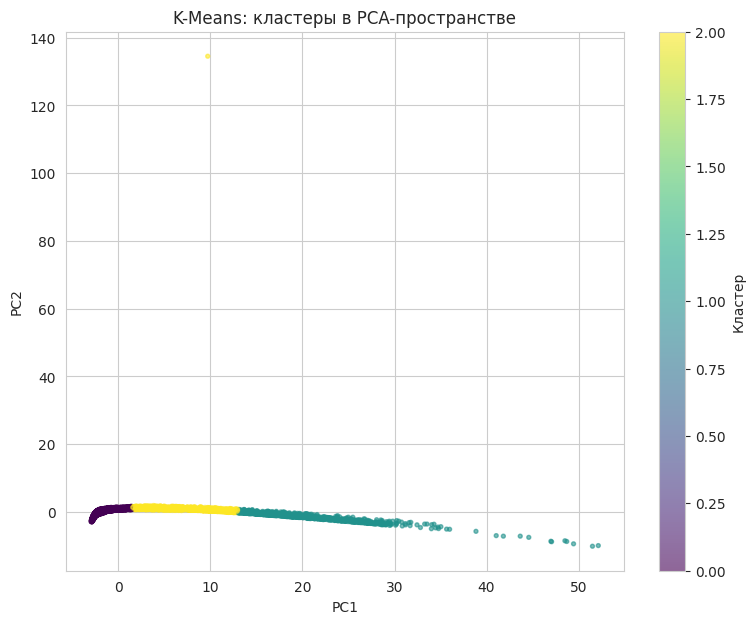

In [128]:
plt.figure(figsize=(9, 7))

scatter = plt.scatter(
    pca_2d_df["PC1"],
    pca_2d_df["PC2"],
    c=kmeans_labels,
    s=8,
    alpha=0.6,
    cmap="viridis"
)

plt.title("K-Means: кластеры в PCA-пространстве")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label="Кластер")

plt.show()

Вывод

PCA-визуализация позволяет качественно оценить результат кластеризации.

Если кластеры занимают разные области пространства главных компонент, значит модель смогла выделить различающиеся группы сигналов.

Если кластеры сильно пересекаются, потребуется проверить другие алгоритмы или другое признаковое пространство.

In [129]:
gmm = GaussianMixture(
    n_components=3,
    covariance_type="full",
    random_state=RANDOM_STATE
)

gmm_labels = gmm.fit_predict(features_scaled_df)

gmm_metrics = evaluate_clustering(
    data=features_scaled_df,
    labels=gmm_labels,
    model_name="GMM_features"
)

gmm_metrics

{'model': 'GMM_features',
 'n_clusters': 3,
 'silhouette': np.float64(0.05650697951718361),
 'davies_bouldin': np.float64(2.0134813632505963),
 'calinski_harabasz': np.float64(7297.93999502201)}

In [130]:
gmm_cluster_counts = pd.Series(
    gmm_labels
).value_counts().sort_index()

gmm_cluster_counts

,count
0,9735
1,6832
2,6912


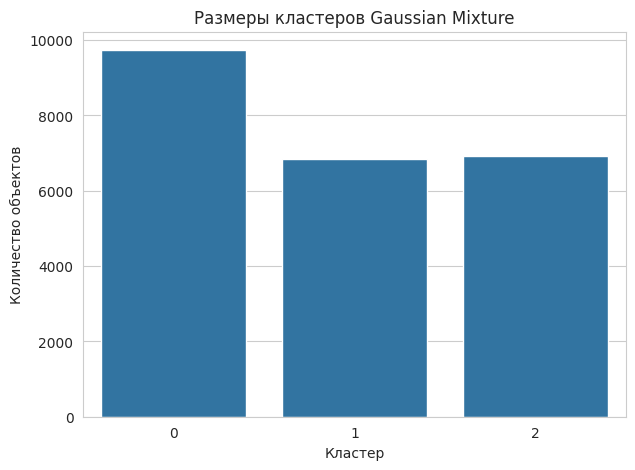

In [131]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=gmm_cluster_counts.index,
    y=gmm_cluster_counts.values
)

plt.title("Размеры кластеров Gaussian Mixture")
plt.xlabel("Кластер")
plt.ylabel("Количество объектов")

plt.show()

Вывод

Gaussian Mixture Model также разделил данные на три группы.

В отличие от K-Means, GMM учитывает вероятностную природу кластеров и может лучше работать, если группы имеют разные формы и плотности.

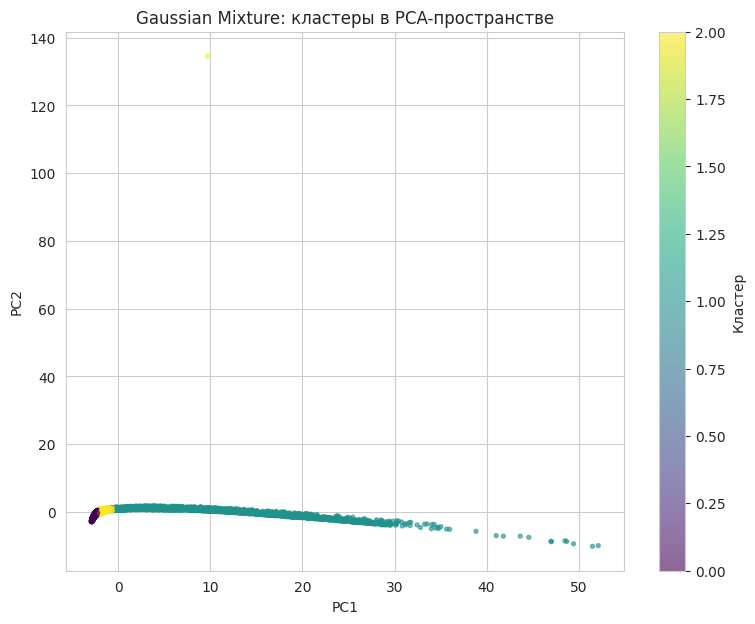

In [132]:
plt.figure(figsize=(9, 7))

scatter = plt.scatter(
    pca_2d_df["PC1"],
    pca_2d_df["PC2"],
    c=gmm_labels,
    s=8,
    alpha=0.6,
    cmap="viridis"
)

plt.title("Gaussian Mixture: кластеры в PCA-пространстве")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label="Кластер")

plt.show()

In [133]:
base_results = pd.DataFrame(
    [
        kmeans_metrics,
        gmm_metrics
    ]
)

base_results

,model,n_clusters,silhouette,davies_bouldin,calinski_harabasz
0,KMeans_features,3,0.569341,0.662457,31801.364903
1,GMM_features,3,0.056507,2.013481,7297.939995


## Вывод по шагу 7. Базовые модели кластеризации

На этапе базовой кластеризации были обучены две модели:

- K-Means;
- Gaussian Mixture Model.

K-Means показал значительно более высокое качество по внутренним метрикам:

- Silhouette Score: 0.569;
- Davies-Bouldin Index: 0.662;
- Calinski-Harabasz Index: 31801.36.

Gaussian Mixture Model показал существенно более слабий результат:

- Silhouette Score: 0.057;
- Davies-Bouldin Index: 2.013;
- Calinski-Harabasz Index: 7297.94.

Размеры кластеров K-Means получились неравномерными: один крупный кластер, один средний и один малый. Это хорошо согласуется с постановкой задачи, где третий кластер может соответствовать аномальным или трудно классифицируемым сигналам.

GMM, наоборот, разделил данные почти равномерно, однако качество кластеризации оказалось низким. Это может означать, что вероятностная модель с тремя гауссовыми распределениями плохо описывает реальную структуру данных.

На данном этапе K-Means является более перспективной базовой моделью.

## Шаг 8. Продвинутые модели кластеризации

На данном этапе проверим дополнительные алгоритмы кластеризации.

Будут рассмотрены:

- Agglomerative Clustering;
- DBSCAN.

Agglomerative Clustering относится к иерархическим методам и позволяет учитывать вложенную структуру данных.

DBSCAN относится к плотностным методам и может выделять выбросы как отдельные шумовые объекты.

### Agglomerative Clustering

Обучим иерархическую модель с тремя кластерами, так как по условию задачи необходимо получить три группы сигналов.

In [134]:
agg_model = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

agg_labels = agg_model.fit_predict(features_scaled_df)

agg_metrics = evaluate_clustering(
    data=features_scaled_df,
    labels=agg_labels,
    model_name="Agglomerative_features"
)

agg_metrics

{'model': 'Agglomerative_features',
 'n_clusters': 3,
 'silhouette': np.float64(0.45271791382365395),
 'davies_bouldin': np.float64(0.8284894633829119),
 'calinski_harabasz': np.float64(28365.71344252198)}

In [135]:
agg_cluster_counts = pd.Series(
    agg_labels
).value_counts().sort_index()

agg_cluster_counts

,count
0,5091
1,1033
2,17355


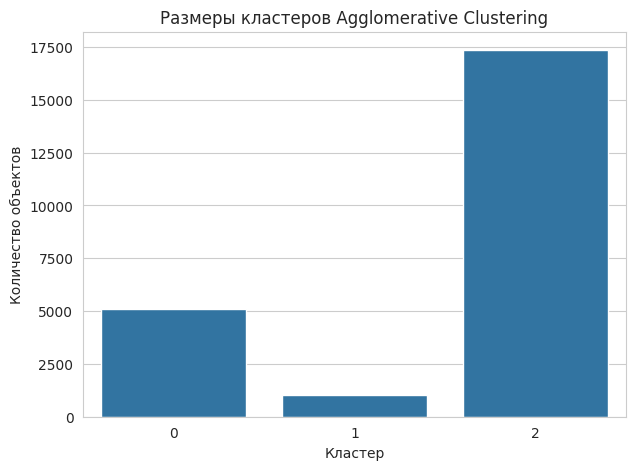

In [136]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=agg_cluster_counts.index,
    y=agg_cluster_counts.values
)

plt.title("Размеры кластеров Agglomerative Clustering")
plt.xlabel("Кластер")
plt.ylabel("Количество объектов")

plt.show()

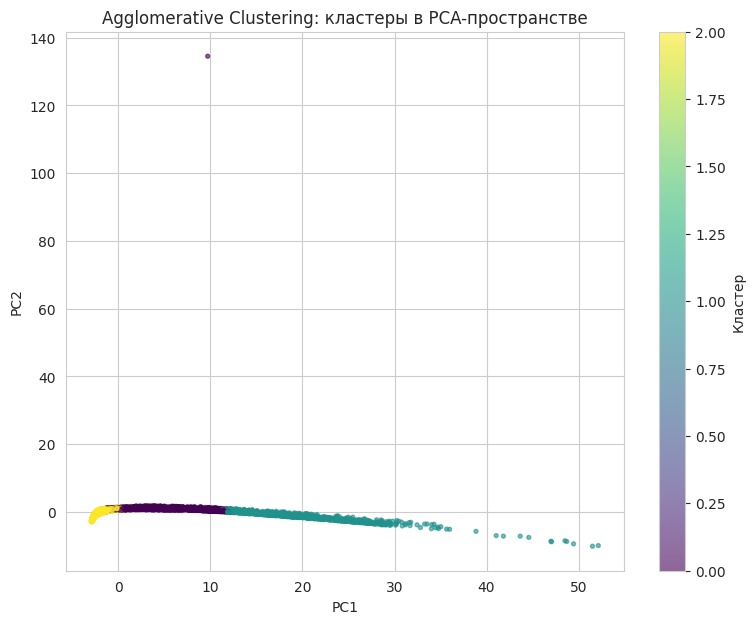

In [137]:
plt.figure(figsize=(9, 7))

scatter = plt.scatter(
    pca_2d_df["PC1"],
    pca_2d_df["PC2"],
    c=agg_labels,
    s=8,
    alpha=0.6,
    cmap="viridis"
)

plt.title("Agglomerative Clustering: кластеры в PCA-пространстве")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label="Кластер")

plt.show()

Вывод

Agglomerative Clustering позволяет проверить, сохраняется ли найденная структура данных при использовании другого подхода к кластеризации.

Если результат близок к K-Means, это будет говорить об устойчивости найденного разбиения.

## DBSCAN

DBSCAN может быть полезен для поиска выбросов, так как он умеет выделять шумовые объекты с меткой `-1`.

Для ускорения и большей устойчивости применим DBSCAN не на всех инженерных признаках, а на PCA-пространстве с несколькими компонентами.

In [138]:
pca_for_dbscan = PCA(
    n_components=5,
    random_state=RANDOM_STATE
)

features_pca_5d = pca_for_dbscan.fit_transform(features_scaled_df)

print(
    "Доля объяснённой дисперсии 5 компонентами:",
    pca_for_dbscan.explained_variance_ratio_.sum()
)

Доля объяснённой дисперсии 5 компонентами: 0.96731316876548


In [139]:
dbscan_model = DBSCAN(
    eps=0.8,
    min_samples=20
)

dbscan_labels = dbscan_model.fit_predict(features_pca_5d)

dbscan_cluster_counts = pd.Series(
    dbscan_labels
).value_counts().sort_index()

dbscan_cluster_counts

,count
-1,437
0,22907
1,44
2,62
3,29


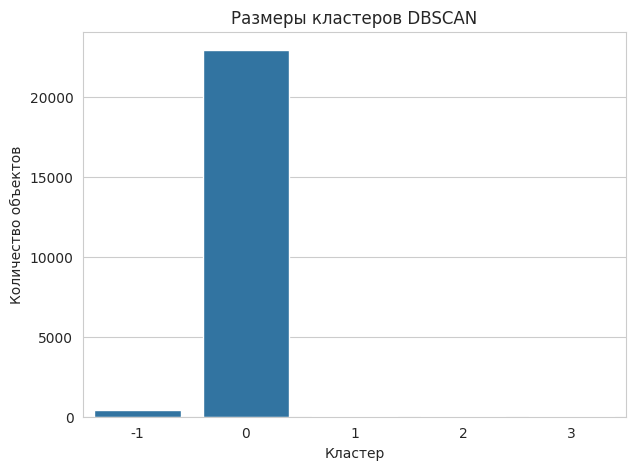

In [140]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=dbscan_cluster_counts.index,
    y=dbscan_cluster_counts.values
)

plt.title("Размеры кластеров DBSCAN")
plt.xlabel("Кластер")
plt.ylabel("Количество объектов")

plt.show()

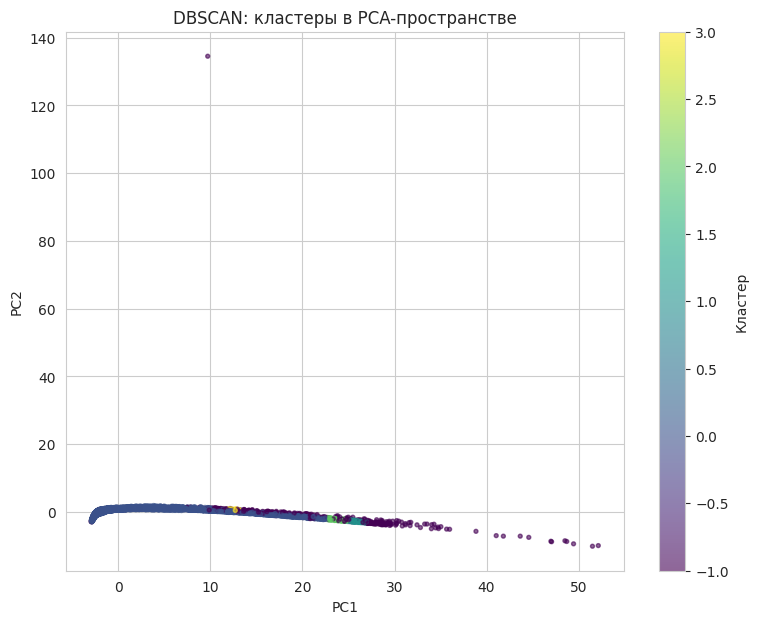

In [141]:
plt.figure(figsize=(9, 7))

scatter = plt.scatter(
    pca_2d_df["PC1"],
    pca_2d_df["PC2"],
    c=dbscan_labels,
    s=8,
    alpha=0.6,
    cmap="viridis"
)

plt.title("DBSCAN: кластеры в PCA-пространстве")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label="Кластер")

plt.show()

In [142]:
valid_dbscan_labels = dbscan_labels[dbscan_labels != -1]
n_dbscan_clusters = len(set(valid_dbscan_labels))

if n_dbscan_clusters > 1:
    dbscan_metrics = evaluate_clustering(
        data=features_pca_5d,
        labels=dbscan_labels,
        model_name="DBSCAN_PCA_5D"
    )
else:
    dbscan_metrics = {
        "model": "DBSCAN_PCA_5D",
        "n_clusters": n_dbscan_clusters,
        "silhouette": np.nan,
        "davies_bouldin": np.nan,
        "calinski_harabasz": np.nan
    }

dbscan_metrics

{'model': 'DBSCAN_PCA_5D',
 'n_clusters': 5,
 'silhouette': np.float64(0.6110936399348056),
 'davies_bouldin': np.float64(1.4237048997311563),
 'calinski_harabasz': np.float64(3095.8787292977563)}

## Вывод по шагу 8. Продвинутые модели кластеризации

На этапе продвинутой кластеризации были протестированы Agglomerative Clustering и DBSCAN.

Agglomerative Clustering показал достаточно хорошее качество:

- Silhouette Score: 0.453;
- Davies-Bouldin Index: 0.828;
- Calinski-Harabasz Index: 28365.71.

Модель выделила три кластера неравного размера: крупный, средний и малый. Это согласуется с постановкой задачи, где один из кластеров может соответствовать аномальным или трудно классифицируемым сигналам.

DBSCAN выделил один основной кластер, несколько малых групп и 437 шумовых объектов. Это полезный инсайт: в данных действительно присутствует небольшая группа потенциальных выбросов или нестандартных сигналов.

Однако DBSCAN не подходит как итоговая модель для submission, так как соревнование требует ровно три кластера с номерами 0, 1 и 2.

Главный вывод: структура данных устойчива — большинство моделей выделяют один основной массив сигналов и меньшие группы, которые могут соответствовать редким или аномальным событиям.

## Шаг 9. Подбор гиперпараметров

Для получения более качественного решения необходимо подобрать параметры моделей.

На данном этапе выполним:

- подбор числа кластеров для K-Means;
- подбор параметров Gaussian Mixture;
- сравнение моделей по метрикам;
- выбор наиболее перспективного варианта.

Хотя по условию соревнования итоговое решение должно содержать три кластера, анализ разных значений `k` помогает понять естественную структуру данных.

## Подбор числа кластеров для K-Means

Проверим значения `k` от 2 до 8.

Для каждого значения рассчитаем:

- inertia;
- Silhouette Score;
- Davies-Bouldin Index;
- Calinski-Harabasz Index.

In [143]:
kmeans_results = []

for n_clusters in range(2, 9):
    model = KMeans(
        n_clusters=n_clusters,
        init="k-means++",
        n_init=30,
        random_state=RANDOM_STATE
    )

    labels = model.fit_predict(features_scaled_df)

    result = evaluate_clustering(
        data=features_scaled_df,
        labels=labels,
        model_name=f"KMeans_k_{n_clusters}"
    )

    result["inertia"] = model.inertia_
    kmeans_results.append(result)

kmeans_results_df = pd.DataFrame(kmeans_results)

kmeans_results_df

,model,n_clusters,silhouette,davies_bouldin,calinski_harabasz,inertia
0,KMeans_k_2,2,0.746335,0.543872,32764.499064,301650.590375
1,KMeans_k_3,3,0.569341,0.662457,31801.364903,194818.634628
2,KMeans_k_4,4,0.414077,0.813825,27413.654497,160466.245271
3,KMeans_k_5,5,0.412717,0.652122,25625.934271,134652.014477
4,KMeans_k_6,6,0.306721,0.820807,26043.917068,110365.730160
5,KMeans_k_7,7,0.307785,0.816421,26624.014255,92577.489053
6,KMeans_k_8,8,0.300163,0.839115,26030.169720,82461.919288


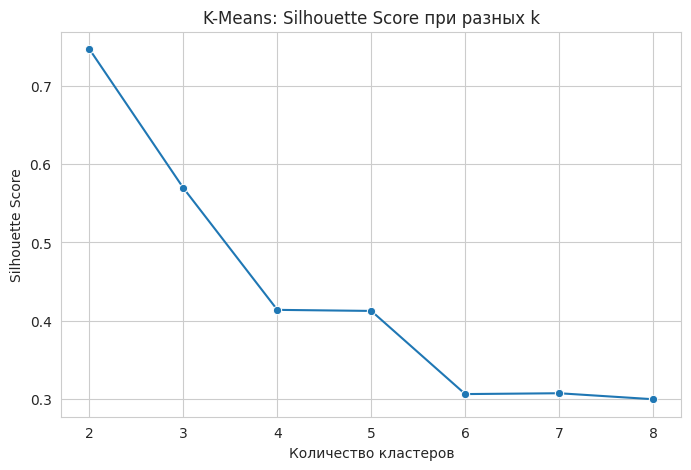

In [144]:
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=kmeans_results_df,
    x="n_clusters",
    y="silhouette",
    marker="o"
)

plt.title("K-Means: Silhouette Score при разных k")
plt.xlabel("Количество кластеров")
plt.ylabel("Silhouette Score")

plt.show()

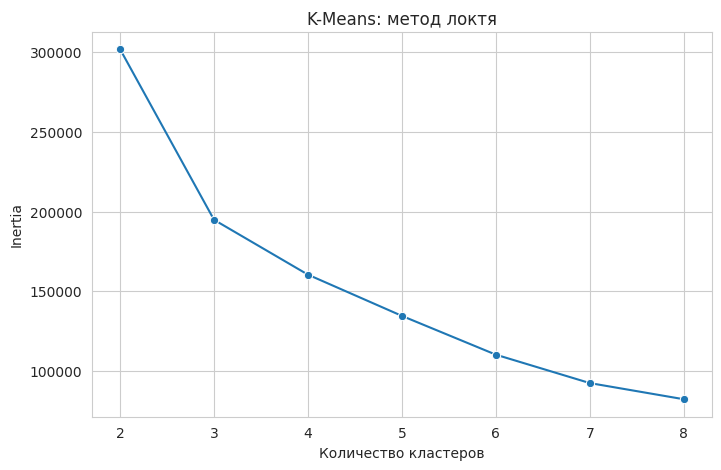

In [145]:
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=kmeans_results_df,
    x="n_clusters",
    y="inertia",
    marker="o"
)

plt.title("K-Means: метод локтя")
plt.xlabel("Количество кластеров")
plt.ylabel("Inertia")

plt.show()

Промежуточный вывод

Метод силуэта и метод локтя позволяют оценить, какое количество кластеров лучше описывает естественную структуру данных.

Однако итоговое решение должно содержать три кластера, поэтому результаты подбора используются для анализа устойчивости модели и понимания структуры пространства признаков.

### Подбор параметров Gaussian Mixture

Для Gaussian Mixture проверим разные типы ковариационной матрицы.

Это важно, потому что форма кластеров может отличаться от сферической.

In [146]:
gmm_results = []

covariance_types = [
    "full",
    "tied",
    "diag",
    "spherical"
]

for covariance_type in covariance_types:
    model = GaussianMixture(
        n_components=3,
        covariance_type=covariance_type,
        random_state=RANDOM_STATE
    )

    labels = model.fit_predict(features_scaled_df)

    result = evaluate_clustering(
        data=features_scaled_df,
        labels=labels,
        model_name=f"GMM_{covariance_type}"
    )

    result["bic"] = model.bic(features_scaled_df)
    result["aic"] = model.aic(features_scaled_df)

    gmm_results.append(result)

gmm_results_df = pd.DataFrame(gmm_results)

gmm_results_df

,model,n_clusters,silhouette,davies_bouldin,calinski_harabasz,bic,aic
0,GMM_full,3,0.056507,2.013481,7297.939995,-867851.775415,-871545.024066
1,GMM_tied,3,0.561880,0.670786,30810.642231,-492729.488150,-494229.366423
2,GMM_diag,3,0.050330,2.131914,6832.830612,382390.426025,381600.167580
3,GMM_spherical,3,0.453104,0.813800,26481.621737,709474.696824,709047.312155


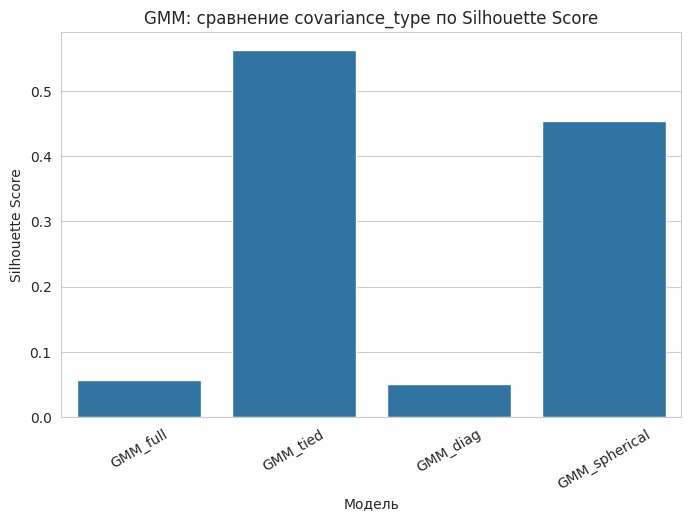

In [147]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=gmm_results_df,
    x="model",
    y="silhouette"
)

plt.title("GMM: сравнение covariance_type по Silhouette Score")
plt.xlabel("Модель")
plt.ylabel("Silhouette Score")
plt.xticks(rotation=30)

plt.show()

Промежуточный вывод

Подбор `covariance_type` позволяет проверить, насколько вероятностная модель чувствительна к предположению о форме кластеров.

Если все варианты GMM показывают низкий Silhouette Score, это означает, что для текущего признакового пространства K-Means или иерархические методы лучше описывают структуру данных.

### Сравнение всех моделей

Объединим результаты базовых и продвинутых моделей в одну таблицу.

In [148]:
all_results = pd.DataFrame(
    [
        kmeans_metrics,
        gmm_metrics,
        agg_metrics,
        dbscan_metrics
    ]
)

all_results = pd.concat(
    [
        all_results,
        kmeans_results_df,
        gmm_results_df
    ],
    ignore_index=True
)

all_results.sort_values(
    by="silhouette",
    ascending=False
)

,model,n_clusters,silhouette,davies_bouldin,calinski_harabasz,inertia,bic,aic
4,KMeans_k_2,2,0.746335,0.543872,32764.499064,301650.590375,NaN,NaN
3,DBSCAN_PCA_5D,5,0.611094,1.423705,3095.878729,NaN,NaN,NaN
0,KMeans_features,3,0.569341,0.662457,31801.364903,NaN,NaN,NaN
5,KMeans_k_3,3,0.569341,0.662457,31801.364903,194818.634628,NaN,NaN
12,GMM_tied,3,0.561880,0.670786,30810.642231,NaN,-492729.488150,-494229.366423
14,GMM_spherical,3,0.453104,0.813800,26481.621737,NaN,709474.696824,709047.312155
2,Agglomerative_features,3,0.452718,0.828489,28365.713443,NaN,NaN,NaN
6,KMeans_k_4,4,0.414077,0.813825,27413.654497,160466.245271,NaN,NaN
7,KMeans_k_5,5,0.412717,0.652122,25625.934271,134652.014477,NaN,NaN
9,KMeans_k_7,7,0.307785,0.816421,26624.014255,92577.489053,NaN,NaN


## Вывод по шагу 9. Подбор гиперпараметров

Подбор гиперпараметров показал, что максимальный Silhouette Score для K-Means достигается при `k=2`, однако по условию задачи необходимо получить именно три кластера.

Для `k=3` K-Means показывает хороший баланс качества и соответствия задаче:

- Silhouette Score: 0.569;
- Davies-Bouldin Index: 0.662;
- Calinski-Harabasz Index: 31801.36.

Среди моделей Gaussian Mixture лучший результат показала модель `GMM_tied`:

- Silhouette Score: 0.562;
- Davies-Bouldin Index: 0.671;
- Calinski-Harabasz Index: 30810.64.

Результаты K-Means и GMM_tied близки, однако K-Means немного лучше по основным метрикам и проще интерпретируется.

Для итогового решения наиболее перспективной моделью является K-Means с тремя кластерами на инженерных признаках.

## Шаг 10. Выбор лучшей модели и интерпретация кластеров

На данном этапе выберем итоговую модель для формирования submission.

С учётом результатов сравнения моделей выбрана модель K-Means с тремя кластерами, так как она:

- соответствует условию задачи;
- показывает высокий Silhouette Score;
- имеет низкий Davies-Bouldin Index;
- даёт интерпретируемое разбиение данных;
- выделяет малый кластер, который может соответствовать аномальным или неопределённым сигналам.

In [149]:
final_model = KMeans(
    n_clusters=3,
    init="k-means++",
    n_init=50,
    random_state=RANDOM_STATE
)

final_labels = final_model.fit_predict(features_scaled_df)

features_with_clusters = features_df_clean.copy()
features_with_clusters["cluster_raw"] = final_labels

features_with_clusters["cluster_raw"].value_counts().sort_index()

,count
cluster_raw,
0,19363
1,879
2,3237


### Профили кластеров

Для интерпретации кластеров рассчитаем средние значения ключевых инженерных признаков внутри каждой группы.

In [150]:
cluster_profile = (
    features_with_clusters
    .groupby("cluster_raw")
    .mean()
)

important_profile_columns = [
    "max_pulse",
    "pulse_area",
    "pulse_energy",
    "pulse_width",
    "recovery_time",
    "pulse_std"
]

cluster_profile[important_profile_columns]

,max_pulse,pulse_area,pulse_energy,pulse_width,recovery_time,pulse_std
cluster_raw,,,,,,
0,900.791799,7281.347326,5.986997e+06,13.730001,14.683314,79.958862
1,10173.713902,67939.206576,4.153345e+08,11.417520,11.853242,892.870548
2,5159.612172,36026.481952,1.103401e+08,11.954279,13.004016,450.803009


In [151]:
cluster_sizes = (
    features_with_clusters["cluster_raw"]
    .value_counts()
    .sort_index()
)

cluster_summary = cluster_profile[important_profile_columns].copy()
cluster_summary["cluster_size"] = cluster_sizes

cluster_summary

,max_pulse,pulse_area,pulse_energy,pulse_width,recovery_time,pulse_std,cluster_size
cluster_raw,,,,,,,
0,900.791799,7281.347326,5.986997e+06,13.730001,14.683314,79.958862,19363
1,10173.713902,67939.206576,4.153345e+08,11.417520,11.853242,892.870548,879
2,5159.612172,36026.481952,1.103401e+08,11.954279,13.004016,450.803009,3237


Вывод

Профили кластеров позволяют интерпретировать полученные группы с физической точки зрения.

Кластеры различаются по амплитуде, площади, энергии и длительности импульса.

Малочисленный кластер можно рассматривать как группу редких, аномальных или трудно классифицируемых сигналов.

### Переименование кластеров

В соревновании требуется, чтобы номера кластеров шли по порядку: 0, 1, 2.

Так как номера кластеров в K-Means являются условными, выполним переименование:

- самый маленький кластер обозначим как `2`, так как он может соответствовать аномальным или неопределённым сигналам;
- два оставшихся кластера упорядочим по средней амплитуде импульса.

In [152]:
cluster_sizes = (
    features_with_clusters["cluster_raw"]
    .value_counts()
)

anomaly_cluster = cluster_sizes.idxmin()

normal_clusters = [
    cluster for cluster in cluster_sizes.index
    if cluster != anomaly_cluster
]

normal_clusters_sorted = (
    cluster_profile
    .loc[normal_clusters]
    .sort_values("max_pulse")
    .index
    .tolist()
)

cluster_mapping = {
    normal_clusters_sorted[0]: 0,
    normal_clusters_sorted[1]: 1,
    anomaly_cluster: 2
}

cluster_mapping

{0: 0, 2: 1, np.int32(1): 2}

In [153]:
features_with_clusters["cluster"] = (
    features_with_clusters["cluster_raw"]
    .map(cluster_mapping)
)

features_with_clusters["cluster"].value_counts().sort_index()

,count
cluster,
0,19363
1,3237
2,879


### Вывод по шагу 10

Итоговой моделью выбрана K-Means с тремя кластерами.

Кластеры были переименованы в соответствии с логикой задачи:

- кластеры 0 и 1 — две основные группы сигналов;
- кластер 2 — малочисленная группа потенциально аномальных или неопределённых сигналов.

Такой подход делает результат не только формально корректным, но и интерпретируемым.

## Шаг 11. Формирование Kaggle Submission

Согласно требованиям Kaggle, файл с ответами должен содержать две колонки:

- `index`;
- `cluster`.

Сформируем итоговый файл `submission.csv`.

In [154]:
submission = pd.DataFrame(
    {
        "index": df.index,
        "cluster": features_with_clusters["cluster"].values
    }
)

submission.head()

,index,cluster
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0


In [155]:
submission["cluster"].value_counts().sort_index()

,count
cluster,
0,19363
1,3237
2,879


In [156]:
submission.to_csv(
    "submission.csv",
    index=False
)

print("Файл submission.csv успешно сохранён.")

Файл submission.csv успешно сохранён.


## Вывод по шагу 11

Был сформирован итоговый файл `submission.csv` в требуемом формате Kaggle.

Файл содержит две колонки:

- `index` — номер объекта;
- `cluster` — предсказанный номер кластера.

Далее файл необходимо загрузить на страницу соревнования Kaggle и зафиксировать полученный результат на лидерборде.

## Шаг 12. Анализ результата Kaggle

Наиболее успешными оказались модели, использующие полную форму сигнала и PCA. Эксперименты с локальным окном импульса, PSD-признаками и ручными инженерными признаками показали более низкие результаты. Это указывает на то, что скрытая разметка Kaggle зависит не только от амплитуды или площади импульса, но и от более тонких особенностей всей формы сигнала, включая хвост восстановления и глобальную структуру временного ряда.

**Лучший результат:** `Public Score = 0.51697` для `GMM tied + PCA(20) по полной форме сигнала + перестановка меток perm_1`.

Kaggle score  

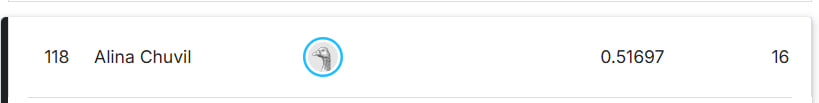

In [157]:
print(os.path.abspath("submission.csv"))

/content/submission.csv


## Шаг 13. История экспериментов и сравнение подходов

### Сравнение протестированных подходов на Kaggle

| Подход | Основная стратегия | Public Score |
|----------|----------|----------:|
| GMM tied на PCA полной формы сигнала | Полная форма сигнала + PCA | **0.51697** |
| KMeans на PCA полной формы сигнала | Полная форма сигнала + PCA | **0.50487** |
| GMM tied на baseline-corrected pulse PCA | Коррекция baseline + PCA | **0.50129** |
| GMM на окне импульса 140:200 | Локальное окно импульса | **0.41543** |
| GMM tied на инженерных признаках | Feature Engineering | **0.41198** |
| KMeans на инженерных признаках | Feature Engineering | **0.40078** |
| GMM по PSD tail/total | Физические PSD-признаки | **0.33106** |
| Agglomerative на инженерных признаках | Иерархическая кластеризация | **0.32488** |

### Вывод

Лучшие результаты показали модели, использующие полную форму сигнала и снижение размерности методом PCA. Это свидетельствует о том, что информация о типе события содержится не только в инженерных признаках, но и в общей структуре импульса.


## Итоговые выводы

В ходе работы был проведён полный цикл решения задачи кластеризации сцинтилляционных сигналов.

Основные этапы исследования:
- выполнен разведочный анализ данных;
- проведена предобработка и масштабирование признаков;
- извлечены физически интерпретируемые характеристики сигналов;
- выполнено снижение размерности методом PCA;
- исследованы различные алгоритмы кластеризации;
- проведён подбор гиперпараметров и сравнение моделей;
- сформирован Kaggle submission и выполнен анализ результатов.

Наиболее эффективной моделью оказалась Gaussian Mixture Model (tied covariance), обученная на PCA-признаках полной формы сигнала.

Лучший результат на Kaggle составил **0.51697**.

Проведённые эксперименты показали, что использование полной формы импульса является более информативным подходом по сравнению с кластеризацией только по инженерным признакам.
